# Simulación de mapa de modos B del CMB

Generación de un mapa de modos B en la aproximación *flat-sky* usando CAMB, separando la contribución de lente gravitacional y la primordial ($r$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import camb
from camb import model, initialpower

In [35]:
# Parámetros cosmológicos fijos
pars = camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06,
                       omk=0, tau=0.06, As=2e-9, ns=0.965,
                       halofit_version='mead', lmax=3000)
pars.set_for_lmax(3000, lens_potential_accuracy=2)
pars.WantTensors = True

# Parámetros fijos para modos B
Alens = 1.0   # amplitud de lente gravitacional
r = 0.1      # razón tensor-escalar

In [36]:
# ---- Componente de lente (r=0) ----
pars_temp = pars.copy()
results = camb.get_results(pars_temp)
inflation_params = initialpower.InitialPowerLaw()
inflation_params.set_params(ns=0.965, r=0.0)
results.power_spectra_from_transfer(inflation_params)

cl_lensed = results.get_total_cls(3000, CMB_unit='muK', raw_cl=True)
cl_unlensed = results.get_unlensed_scalar_cls(3000, CMB_unit='muK', raw_cl=True)
bb_lensing = cl_lensed[:, 2] - cl_unlensed[:, 2]

# ---- Componente tensorial (r=0.1 como referencia) ----
r_ref = 0.1
pars_temp2 = pars.copy()
results2 = camb.get_results(pars_temp2)
inflation_params2 = initialpower.InitialPowerLaw()
inflation_params2.set_params(ns=0.965, r=r_ref)
results2.power_spectra_from_transfer(inflation_params2)
cl_tensor = results2.get_tensor_cls(3000, CMB_unit='muK', raw_cl=True)
bb_tensor_ref = cl_tensor[:, 2]

ell = np.arange(3001)

# ---- Espectro combinado ----
bb_total = Alens * bb_lensing + (r / r_ref) * bb_tensor_ref

# D_ell
dBB = bb_total.copy()
dBB[2:] = bb_total[2:] * ell[2:] * (ell[2:] + 1) / (2 * np.pi)
dBB[:2] = 0

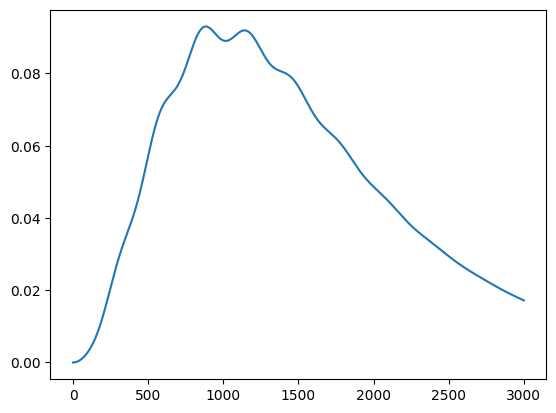

In [37]:
dBB = bb_lensing.copy()
dBB[2:] = bb_lensing[2:] * ell[2:] * (ell[2:] + 1) / (2 * np.pi)
dBB[:2] = 0
plt.plot(dBB)

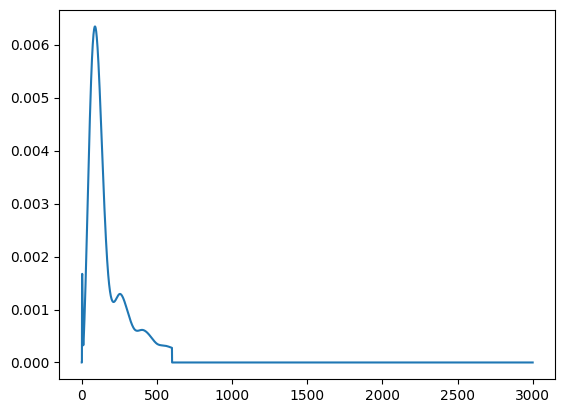

In [38]:
dBB = bb_tensor_ref.copy()
dBB[2:] = bb_tensor_ref[2:] * ell[2:] * (ell[2:] + 1) / (2 * np.pi)
dBB[:2] = 0
plt.plot(dBB)

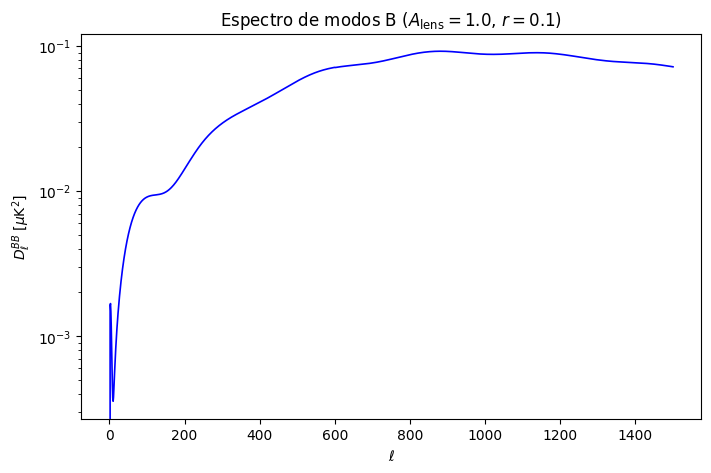

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(ell, dBB, 'b-', lw=1.2)
plt.yscale('log')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell^{BB}$ [$\mu$K$^2$]')
plt.title(r'Espectro de modos B ($A_{\mathrm{lens}}=' + f'{Alens}$, $r={r}$)')
plt.show()

In [5]:
def make_CMB_B_map(N, pix_size, ell, ClBB):
    Cl = ClBB.copy()
    Cl[0] = 0.0
    if len(Cl) > 1:
        Cl[1] = 0.0
    inds = np.linspace(-0.5, 0.5, N)
    X, Y = np.meshgrid(inds, inds)
    R = np.sqrt(X**2 + Y**2)
    pix_to_rad = (pix_size / 60.0) * np.pi / 180.0
    ell_scale = 2.0 * np.pi / pix_to_rad
    ell2d = R * ell_scale
    Cl_expanded = np.zeros(int(ell2d.max()) + 1)
    n_copy = min(Cl.size, len(Cl_expanded))
    Cl_expanded[:n_copy] = Cl[:n_copy]
    Cl2d = Cl_expanded[ell2d.astype(int)]
    Cl2d = np.maximum(Cl2d, 0)
    random = np.random.normal(0, 1, (N, N))
    FT_random = np.fft.fft2(random)
    FT_2d = np.sqrt(Cl2d) * FT_random
    B_map = np.fft.ifft2(np.fft.fftshift(FT_2d))
    B_map = np.real(B_map) / pix_to_rad
    return B_map

def plot_map(Map, c_min, c_max, Xw, Yw):
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    print("map mean:",np.mean(Map),"map rms:",np.std(Map))
    plt.gcf().set_size_inches(10, 10)
    im = plt.imshow(Map, interpolation='bilinear', origin='lower',cmap=cm.RdBu_r)
    im.set_clim(c_min,c_max)
    im.set_extent([0,Xw,0,Yw])
    plt.ylabel(r"Angle $[^\circ]$")
    plt.xlabel(r"Angle $[^\circ]$")

    ax = plt.gca()
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(im, cax=cax, label="Temperature [uK]")

In [6]:
N = 2**7
pix_size = 4.0
Xw = N * pix_size / 60.0
Yw = N * pix_size / 60.0
np.random.seed(42)

map mean: 0.18304180840152945 map rms: 4.962929866012459


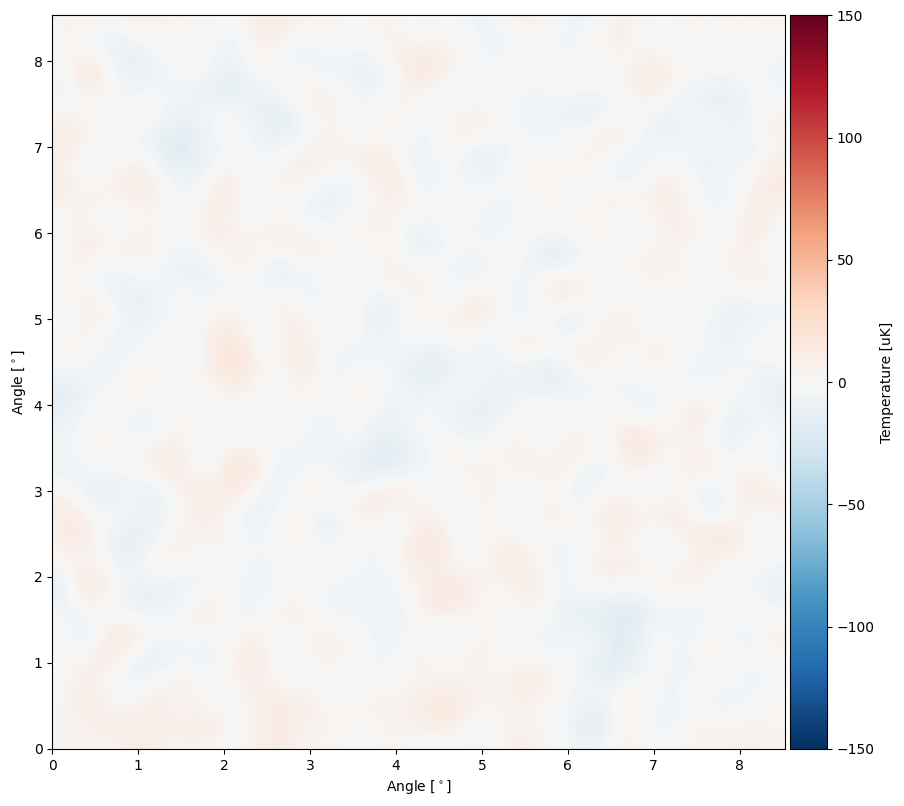

In [7]:
b_map = make_CMB_B_map(N, pix_size, ell, bb_total)
plot_map(b_map, -150, 150, Xw, Yw)

## Recuperación del espectro de potencias desde el mapa

Para recuperar $C_\ell^{BB}$ desde el mapa flat-sky: (1) FFT del mapa, (2) $|\mathrm{FFT}|^2$, (3) promediado azimutal en anillos de $|k|$ constante.

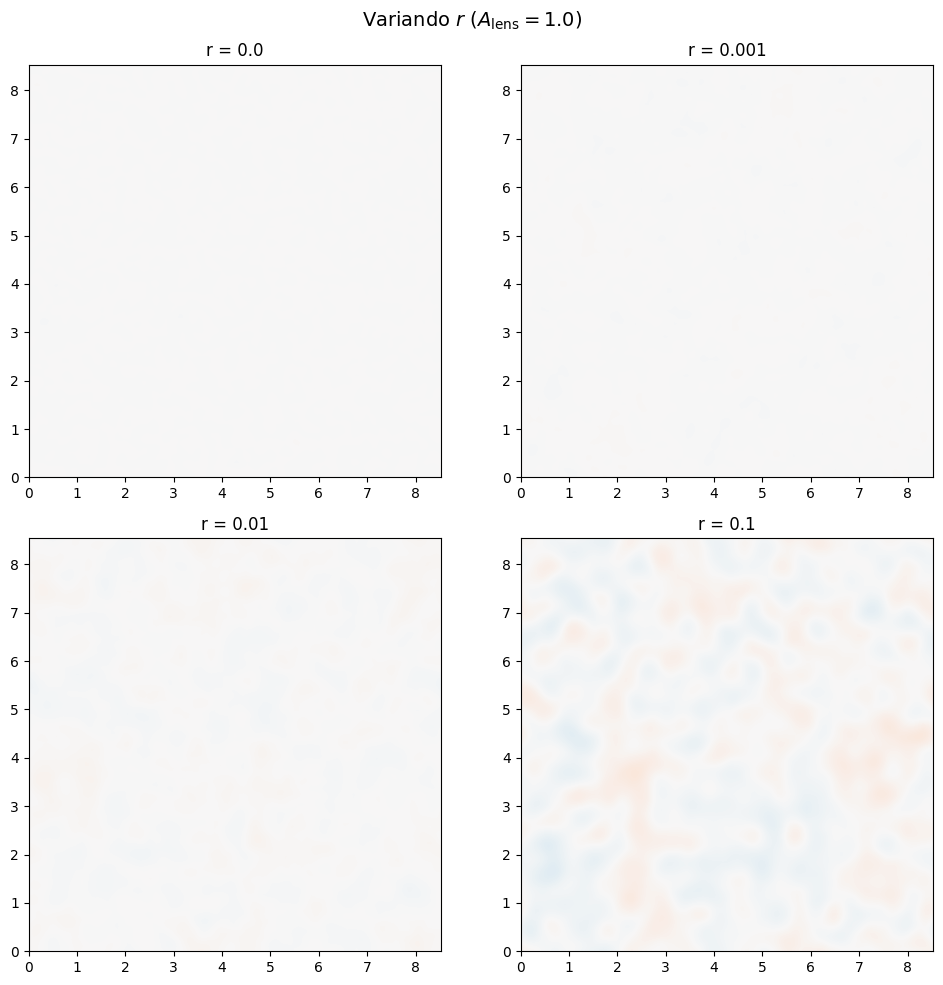

In [8]:
r_vals = [0.0, 0.001, 0.01, 0.1]
Alens_fixed = 1.0

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, r_val in zip(axes.flat, r_vals):
    bb = Alens_fixed * bb_lensing + (r_val / r_ref) * bb_tensor_ref
    b_map = make_CMB_B_map(N, pix_size, ell, bb)
    ax.imshow(b_map, interpolation='bilinear', origin='lower', cmap=cm.RdBu_r,
              vmin=-150, vmax=150, extent=[0, Xw, 0, Yw])
    ax.set_title(f'r = {r_val}')
plt.suptitle('Variando $r$ ($A_{\\mathrm{lens}} = 1.0$)', fontsize=14)
plt.tight_layout()
plt.show()

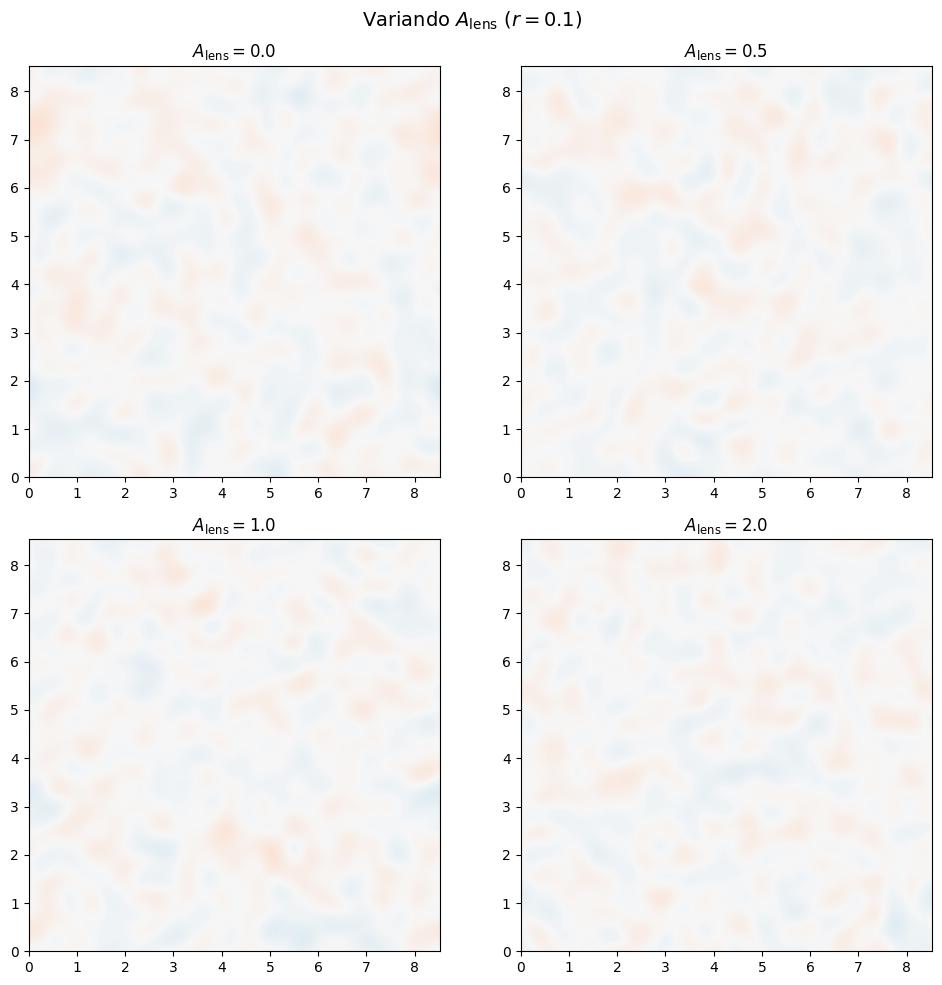

In [9]:
Alens_vals = [0.0, 0.5, 1.0, 2.0]
r_fixed = 0.1

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, Al_val in zip(axes.flat, Alens_vals):
    bb = Al_val * bb_lensing + (r_fixed / r_ref) * bb_tensor_ref
    b_map = make_CMB_B_map(N, pix_size, ell, bb)
    ax.imshow(b_map, interpolation='bilinear', origin='lower', cmap=cm.RdBu_r,
              vmin=-150, vmax=150, extent=[0, Xw, 0, Yw])
    ax.set_title(f'$A_{{\\mathrm{{lens}}}} = {Al_val}$')
plt.suptitle('Variando $A_{\\mathrm{lens}}$ ($r = 0.1$)', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
b_map.shape

(128, 128)